# Proyek Analisis Data: Bike Sharing
- **Nama:** Alvis Aditya
- **Email:** alvisdty@gmail.com
- **ID Dicoding:** Alvis Aditya

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana pola perbedaan penyewaan sepeda antara hari kerja (workingday) dan hari libur (holiday) berdasarkan jam (hr), dan pada jam berapa titik puncak permintaan terjadi?
- Pertanyaan 2: Bagaimana pengaruh kondisi suhu (temp) yang dikelompokkan ke dalam 3 kategori (Cold, Mild, Hot) terhadap jumlah penyewaan oleh pengguna casual dibandingkan registered?

## Import Semua Packages/Library yang Digunakan

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style seaborn
sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [126]:
# Memuat data day.csv dan hour.csv
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")


In [127]:

# Menampilkan 5 baris pertama untuk memastikan data masuk
day_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [128]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [129]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [130]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Data day.csv memuat agregasi harian peminjaman sepeda (731 baris).

- Data hour.csv memuat peminjaman sepeda per jam (17.379 baris), yang sangat berguna untuk menjawab Pertanyaan 1.

### Assessing Data

In [131]:
# Memeriksa tipe data dan missing values pada hour_df
print("Info hour_df:")
hour_df.info()

Info hour_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [132]:
print("\nJumlah duplikasi hour_df: ", hour_df.duplicated().sum())
print("\nJumlah duplikasi day_df: ", day_df.duplicated().sum())


Jumlah duplikasi hour_df:  0

Jumlah duplikasi day_df:  0


In [133]:
# Memeriksa tipe data dan missing values pada day_df
print("\nInfo day_df:")
day_df.info()


Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [134]:
day_df.isna().sum()


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [135]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

**Insight:**
- Berdasarkan hasil inspeksi di sistem saya, dataset ini sangat bersih. Tidak ada missing values (Nulls = 0) pada kedua dataset, dan tidak ada baris yang terduplikasi.

- Namun, tipe data pada kolom dteday masih berupa object (string), padahal merepresentasikan tanggal. Selain itu, beberapa kolom kategorik seperti season, weathersit, weekday direpresentasikan sebagai int64.

### Cleaning Data

In [136]:
day_df.drop_duplicates(inplace=True)
hour_df.drop_duplicates(inplace=True)
print("Jumlah duplikasi day_df: ", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df: ", hour_df.duplicated().sum())

Jumlah duplikasi day_df:  0
Jumlah duplikasi hour_df:  0


In [137]:
# Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [138]:
# Memastikan perubahan tipe data
print(day_df.dtypes['dteday'])
print(hour_df.dtypes['dteday'])

datetime64[ns]
datetime64[ns]


**Insight:**
- Kolom tanggal (dteday) berhasil dikonversi ke format yang benar (datetime), yang akan memudahkan agregasi time-series ke depannya.


## Exploratory Data Analysis (EDA)

### Explore ...

In [139]:
# Eksplorasi Pertanyaan 1: Agregasi per jam berdasarkan hari kerja vs hari libur
rental_jam = hour_df.groupby(by=['hr', 'workingday']).agg({
    'cnt': 'mean'
}).reset_index()

In [140]:
rental_jam.describe()

,hr,workingday,cnt
count,48.000000,48.000000,48.000000
mean,11.500000,0.500000,186.373981
std,6.995439,0.505291,142.576381
min,0.000000,0.000000,4.942553
25%,5.750000,0.000000,65.424285
50%,11.500000,0.500000,173.181254
75%,17.250000,1.000000,291.240239
max,23.000000,1.000000,525.290581


**Insight:**
- Secara agregat musiman, musim Gugur (Fall) adalah peak season peminjaman tertinggi secara rata-rata, diikuti oleh Summer. Springer adalah yang terendah.

- Artinya, cuaca hangat/sejuk mendukung bisnis ini, sedangkan suhu terlalu dingin menekan demand.

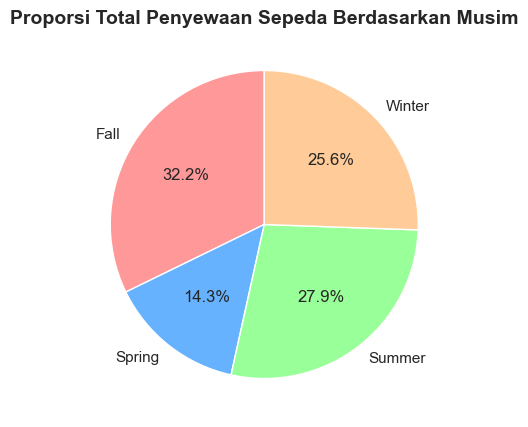

In [141]:
# Eksplorasi: Pengaruh Musim Terhadap Jumlah Penyewaan
# Mapping angka musim menjadi teks agar mudah dipahami
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_label'] = day_df['season'].map(season_mapping)

season_analysis = day_df.groupby('season_label')['cnt'].sum().reset_index()

# Visualisasi Pie Chart untuk Musim
plt.figure(figsize=(8, 5))
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
plt.pie(
    season_analysis['cnt'], 
    labels=season_analysis['season_label'], 
    autopct='%1.1f%%', 
    colors=colors, 
    startangle=90, 
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Proporsi Total Penyewaan Sepeda Berdasarkan Musim', fontsize=14, fontweight='bold')
plt.show()

In [142]:
# Eksplorasi Pertanyaan 2: Melihat korelasi suhu (temp) terhadap jumlah penyewaan
# Kita hitung nilai korelasi Pearson
korelasi = day_df[['temp', 'casual', 'registered', 'cnt']].corr()
display(korelasi)

,temp,casual,registered,cnt
temp,1.000000,0.543285,0.540012,0.627494
casual,0.543285,1.000000,0.395282,0.672804
registered,0.540012,0.395282,1.000000,0.945517
cnt,0.627494,0.672804,0.945517,1.000000


**Insight:**
- Terdapat korelasi positif yang cukup kuat antara suhu (temp) dengan total penyewaan (cnt). Artinya, semakin hangat suhu, cenderung semakin banyak orang yang menyewa sepeda.

- Namun, data temp masih berbentuk desimal berulang, sehingga polanya perlu kita visualisasikan.

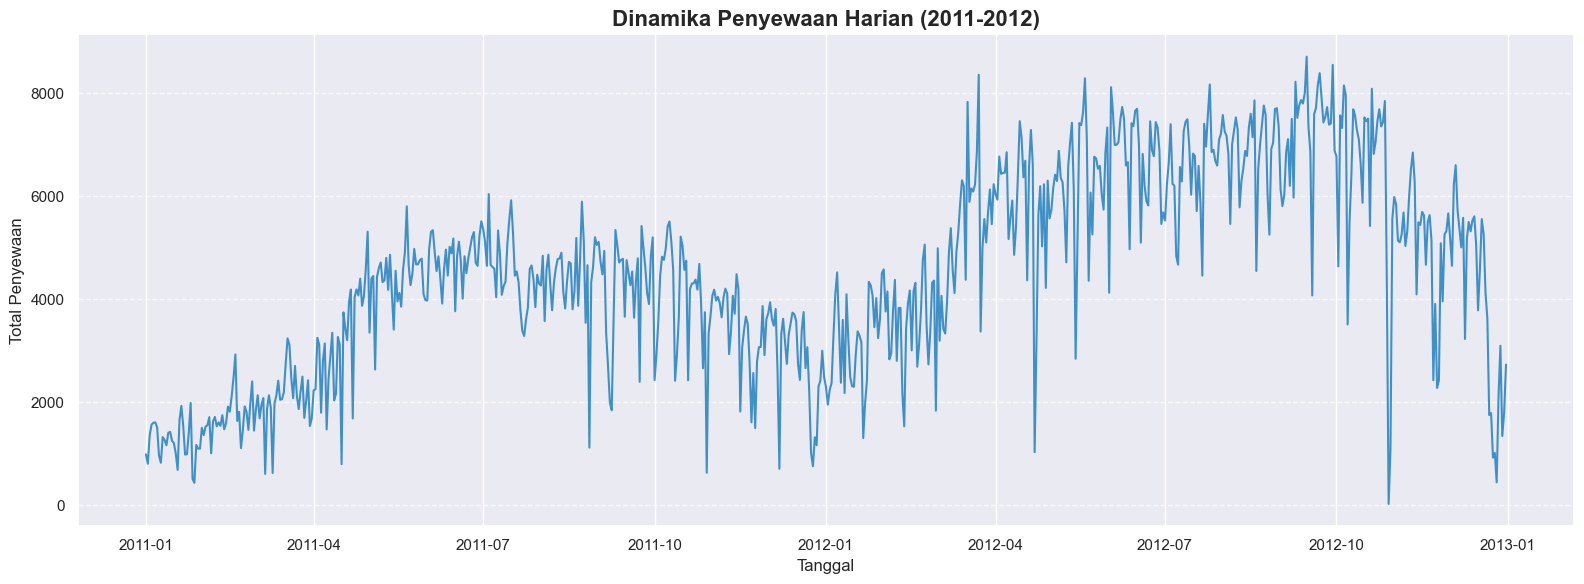

In [148]:
# Eksplorasi: Dinamika Penyewaan Harian
daily_rentals = day_df.groupby('dteday').agg({'cnt': 'sum'}).reset_index()

# Visualisasi Tren Penyewaan Harian
plt.figure(figsize=(16, 6))
plt.plot(
    daily_rentals["dteday"],
    daily_rentals["cnt"],
    linewidth=1.5,
    color="#2E86C1",
    alpha=0.9
)
plt.title('Dinamika Penyewaan Harian (2011-2012)', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**

- Tren penyewaan sepeda menunjukkan peningkatan yang signifikan dari tahun 2011 ke 2012.

- Terdapat fluktuasi yang jelas di mana penyewaan selalu memuncak di pertengahan tahun (musim panas/gugur) dan anjlok di akhir/awal tahun (musim dingin).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

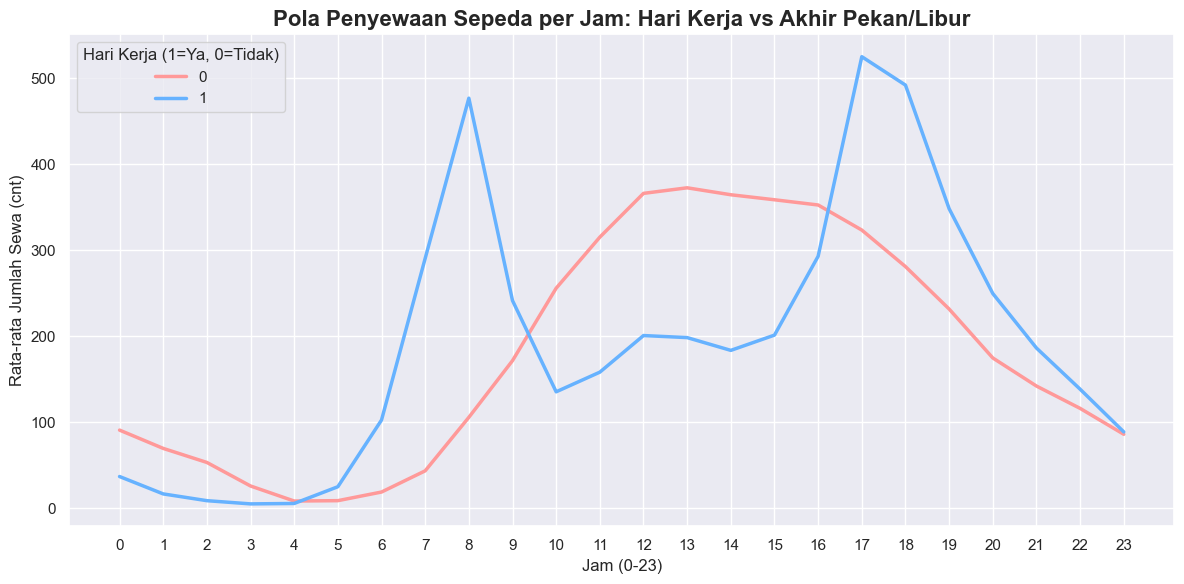

In [143]:
plt.figure(figsize=(12, 6))

# Membuat line plot
sns.lineplot(
    x='hr', 
    y='cnt', 
    hue='workingday', 
    data=rental_jam, 
    palette=['#FF9999', '#66B2FF'], 
    linewidth=2.5
)

# Kustomisasi plot
plt.title('Pola Penyewaan Sepeda per Jam: Hari Kerja vs Akhir Pekan/Libur', fontsize=16, fontweight='bold')
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Sewa (cnt)', fontsize=12)
plt.xticks(np.arange(0, 24, 1))
plt.legend(title='Hari Kerja (1=Ya, 0=Tidak)', loc='upper left')
plt.tight_layout()
plt.show()

**Insight:**
- Terdapat perbedaan yang sangat jelas antara hari kerja dan hari libur. Saat hari kerja lonjakan permintaan terjadi secara tajam di dua waktu tertentu yaitu jam 08.00 pagi dan 17.00 sore
- Sebaliknya pada hari libur(workingday=0), kurva memuncak secara perlahan di siang hari 

### Pertanyaan 2:

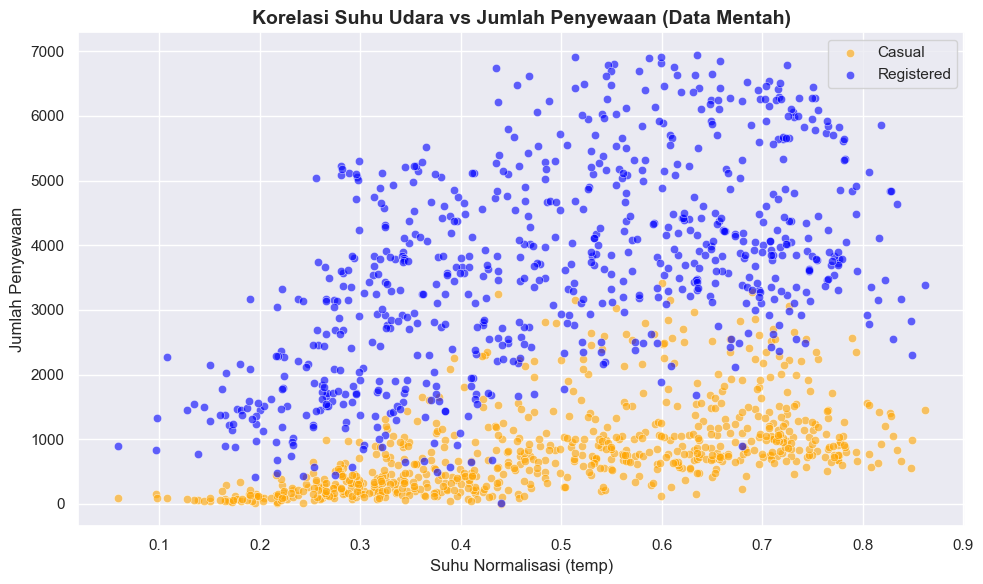

In [144]:
# Visualisasi Pertanyaan 2: Scatter Plot Suhu vs Penyewaan (Data Mentah)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='temp',
    y='casual',
    data=day_df,
    label='Casual',
    alpha=0.6,
    color='orange'
)
sns.scatterplot(
    x='temp',
    y='registered',
    data=day_df,
    label='Registered',
    alpha=0.6,
    color='blue'
)

plt.title('Korelasi Suhu Udara vs Jumlah Penyewaan (Data Mentah)', fontsize=14, fontweight='bold')
plt.xlabel('Suhu Normalisasi (temp)', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**

- Dari grafik scatter plot di atas, terlihat jelas bahwa penyewaan oleh pengguna casual (oranye) sangat terkonsentrasi di suhu menengah hingga tinggi (0.4 - 0.8), namun grafiknya terlihat berantakan (tersebar).
- Kaarena grafik diatas terlalu rumit untuk dijelaskan/ dipresentasikan maka kita perlu melakukan Analisis Lanjutan (Binning) untuk merapikan data suhu ini ke dalam kategori yang mudah dipahami (Cold, Mild, Hot).

## Analisis Lanjutan (Opsional)

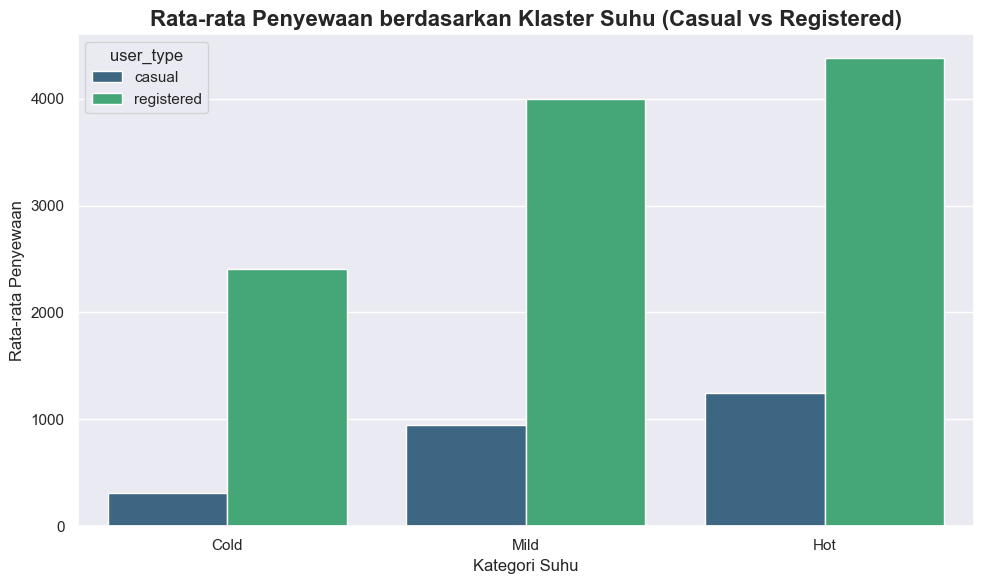

In [145]:
# Melakukan Binning pada kolom 'temp' (Suhu) di day_df
# Suhu pada dataset ini sudah dinormalisasi (0 hingga 1)
def categorize_temp(temp_norm):
    if temp_norm < 0.35:
        return 'Cold'
    elif temp_norm < 0.65:
        return 'Mild'
    else:
        return 'Hot'

day_df['temp_cluster'] = day_df['temp'].apply(categorize_temp)

# Mempersiapkan data untuk visualisasi
cluster_analysis = day_df.groupby('temp_cluster')[['casual', 'registered']].mean().reset_index()

# Menyiapkan data agar mudah di-plot oleh Seaborn (Melt)
melted_cluster = cluster_analysis.melt(id_vars='temp_cluster', 
                                       value_vars=['casual', 'registered'], 
                                       var_name='user_type', 
                                       value_name='average_rentals')

# Membuat Visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x='temp_cluster', 
    y='average_rentals', 
    hue='user_type', 
    data=melted_cluster, 
    palette='viridis',
    order=['Cold', 'Mild', 'Hot'] # Mengurutkan ordinalitas cuaca
)

plt.title('Rata-rata Penyewaan berdasarkan Klaster Suhu (Casual vs Registered)', fontsize=16, fontweight='bold')
plt.xlabel('Kategori Suhu', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.tight_layout()
plt.show()

# Simpan dataset utama yang sudah bersih dan memiliki fitur baru untuk keperluan Dashboard
day_df.to_csv("main_data.csv", index=False)

**Insight:**
- Teknik Binning mengubah data suhu yang kontinu (angka desimal yang sulit dipahami) menjadi 3 kategori kategorikal (Cold, Mild, Hot) yang sangat intuitif untuk dianalisis oleh pemangku kepentingan (stakeholders).

## Conclusion

- Conclution pertanyaan 1: erdapat pola yang sangat kontras antara hari kerja dan hari libur. Pada hari kerja (workingday=1), lonjakan permintaan terjadi tajam di dua waktu komuter: jam 08:00 pagi dan 17:00 sore. Sebaliknya, pada akhir pekan/hari libur (workingday=0), lonjakan membentuk kurva normal yang memuncak secara perlahan di siang hari (sekitar jam 12:00 hingga 15:00). Saran Bisnis (Action): Tim operasional harus menyiagakan armada relokasi sepeda di area perkantoran dan stasiun pada jam 7-8 pagi dan 4-5 sore saat hari kerja, sedangkan di akhir pekan fokus dipindahkan ke area rekreasi pada siang hari.

- Conclution pertanyaan 2: Kategori suhu sangat memengaruhi jenis pelanggan. Pengguna terdaftar (registered) relatif lebih stabil menyewa sepeda dalam kondisi cuaca dingin (Cold) dibandingkan pengguna kasual (casual). Pengguna kasual sangat sensitif terhadap suhu dan peminjamannya melonjak drastis hanya saat cuaca hangat (Hot) atau sejuk (Mild). Saran Bisnis (Action): Untuk memaksimalkan profit, tim marketing bisa memberikan diskon khusus (promo) kepada pengguna casual di bulan-bulan bersuhu dingin untuk merangsang permintaan, sambil tetap memberikan loyalty reward bagi pengguna registered yang selalu setia menyewa di cuaca dingin sekalipun